In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve

# Download Kepler light curve
lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize()
lc.plot()






In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve

lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize()

pd_lombscargle = lc.to_periodogram(method="Lombscargle", period=np.arange(0.5, 10, 0.01))
pd_bls = lc.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.01))

period_lombscargle = pd_lombscargle.period_at_max_power
period_bls = pd_bls.period_at_max_power

print(f"Lomb-Scargle period: {period_lombscargle:.4f} days")
print(f"BLS period: {period_bls:.4f} days")

pd_lombscargle.plot(title="Lomb-Scargle Periodogram", xlabel="Period (days)", ylabel="Power")
pd_bls.plot(title="BLS Periodogram", xlabel="Period (days)", ylabel="Power")


/opt/anaconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


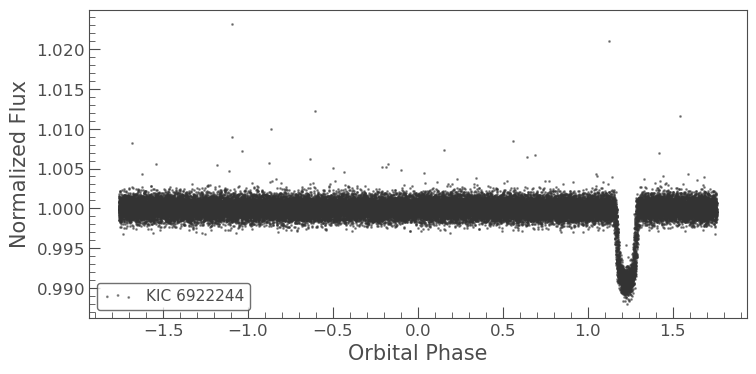

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_lightcurve

lc = lk.search_lightcurve("KIC 6922244", author="Kepler", quarter=4).download().remove_nans().normalize()

pd_bls = lc.to_periodogram(method="bls", period=np.arange(0.5, 10, 0.01))
period_bls = pd_bls.period_at_max_power

ax =lc.fold(period=period_bls).scatter(alpha=0.5)
ax.set_xlabel("Orbital Phase")
plt.show()